In [3]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
import seaborn as sns
from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [4]:
path = '/Users/harryclark/Downloads/COHORT12/xgboost'
data = pd.DataFrame()
for i, file in enumerate(os.listdir(path)):
    print(f'Reading {file}, {i+1}/{len(os.listdir(path))}')
    file_path = os.path.join(path, file)
    if file.endswith('.pkl'):
        df = pd.read_pickle(file_path)
    elif file.endswith('.csv'):
        df = pd.read_csv(file_path)
    data = pd.concat([data, df], ignore_index=True)

Reading M25_D25_C172.csv, 1/1070
Reading M27_D23_C291.csv, 2/1070
Reading M26_D15_C199.csv, 3/1070
Reading M26_D18_C262.csv, 4/1070
Reading M25_D24_C172.csv, 5/1070
Reading M25_D19_C94.csv, 6/1070
Reading M26_D18_C35.csv, 7/1070
Reading M26_D15_C16.csv, 8/1070
Reading M26_D15_C166.csv, 9/1070
Reading M26_D15_C172.csv, 10/1070
Reading M25_D25_C199.csv, 11/1070
Reading M25_D20_C193.csv, 12/1070
Reading M27_D26_C264.csv, 13/1070
Reading M27_D26_C258.csv, 14/1070
Reading M25_D21_C144.csv, 15/1070
Reading M26_D19_C24.csv, 16/1070
Reading M25_D21_C150.csv, 17/1070
Reading M25_D21_C178.csv, 18/1070
Reading M27_D24_C237.csv, 19/1070
Reading M25_D25_C204.csv, 20/1070
Reading M25_D24_C210.csv, 21/1070
Reading M25_D24_C204.csv, 22/1070
Reading M25_D25_C210.csv, 23/1070
Reading M26_D19_C100.csv, 24/1070
Reading M25_D25_C238.csv, 25/1070
Reading M27_D24_C394.csv, 26/1070
Reading M27_D24_C380.csv, 27/1070
Reading M26_D18_C128.csv, 28/1070
Reading M26_D15_C238.csv, 29/1070
Reading M27_D24_C357.csv, 3

In [5]:
# subset dataframe to look at random order_by and session-wide pR2 
random_data = data[(data['ordering'] == 'random') &
            (data['tested_on'] != 'other')]

nearest_data = data[(data['ordering'] == 'nearest') &
            (data['tested_on'] != 'other')]

farthest_data = data[(data['ordering'] == 'farthest') &
            (data['tested_on'] != 'other')]

In [6]:
def subset_by_n_neurons(df, trained_on='GC', n_neurons=5):
    """
    Subset the dataframe to only include rows with a mouse_day_cluster_id rows which are from sessions with sufficient number of neurons.
    Args:
        df (pd.DataFrame): The input dataframe containing neuron data.
        trained_on (str): The type of neurons to filter on, e.g., 'GC' for grid cells. or 'NGS' for non-grid cells.
        n_neurons (int): The number of neurons to filter by.
    Returns:
        pd.DataFrame: A filtered dataframe
    """
    df = df[df['trained_on'] == trained_on]
    df['mouse_day_cluster_id'] = df['mouse'].astype(str) + '_' + df['day'].astype(str) + '_' + df['cluster_id'].astype(str)
    mouse_day_cluster_id_with_enough_neurons = df[df['n_neurons'] >= n_neurons]['mouse_day_cluster_id'].unique()
    df = df[df['mouse_day_cluster_id'].isin(mouse_day_cluster_id_with_enough_neurons)]
    return df[df['n_neurons'] <= n_neurons]

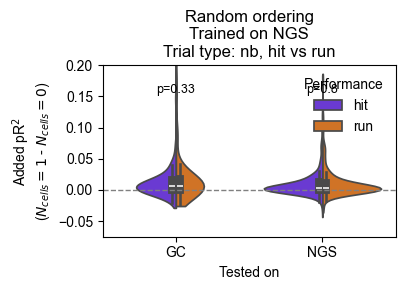

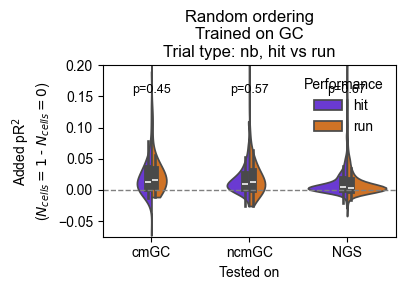

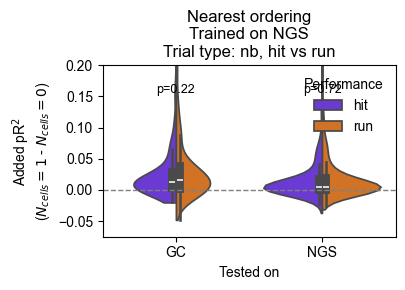

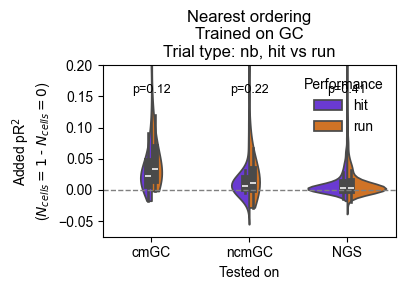

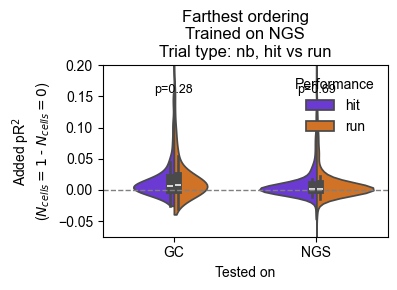

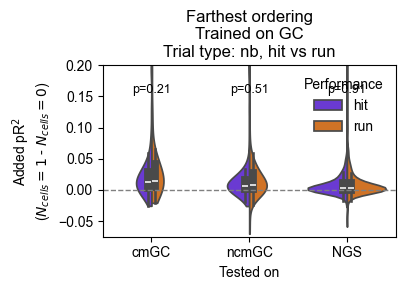

In [20]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# Subset data for trial_type 'nb' and trial_performance hit/run, and trained_on
def get_added_pR2_perf(source_data, trial_type, trained_on):
    added_pR2 = []
    for trial_perf in ['hit', 'run']:
        df = source_data[
            (source_data['trial_type'] == trial_type) &
            (source_data['trial_performance'] == trial_perf) &
            (source_data['trained_on'] == trained_on) &
            (source_data['n_neurons'].isin([0, 1]))
        ]
        if trained_on == 'GC':
            test_on_list = ['cmGC', 'ncmGC', 'NGS']
        else:
            test_on_list = ['GC', 'NGS']

        for tested_on in test_on_list:
            df_plot = df[df['tested_on'] == tested_on]
            # Ensure both n_neurons=0 and n_neurons=1 are present
            if not set([0, 1]).issubset(df_plot['n_neurons'].unique()):
                continue
            pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
            pivot = pivot.dropna(subset=[0, 1])
            if 0 not in pivot.columns or 1 not in pivot.columns:
                continue
            diff = pivot[1] - pivot[0]
            temp_df = pd.DataFrame({
                'added_pR2': diff,
                'tested_on': tested_on,
                'trial_performance': trial_perf
            })
            added_pR2.append(temp_df)
    if added_pR2:
        return pd.concat(added_pR2, ignore_index=True)
    else:
        return pd.DataFrame(columns=['added_pR2', 'tested_on', 'trial_performance'])

# Collect data for each source, trial_performance, and trained_on
all_added_pR2_perf = []
for source, source_data in zip(['random', 'nearest', 'farthest'], [random_data, nearest_data, farthest_data]):
    for trained_on in ['NGS', 'GC']:
        temp = get_added_pR2_perf(source_data, 'nb', trained_on)
        temp['source'] = source
        temp['trained_on'] = trained_on
        all_added_pR2_perf.append(temp)
all_added_pR2_perf = pd.concat(all_added_pR2_perf, ignore_index=True)

palette = {'GC': '#CAC841', 'NGS': '#6897CD'}
perf_palette = {'hit': "#6121EB", 'run': "#EC700A"}

for source in ['random', 'nearest', 'farthest']:
    for trained_on in ['NGS', 'GC']:
        plt.figure(figsize=(4, 3))
        subset = all_added_pR2_perf[
            (all_added_pR2_perf['source'] == source) &
            (all_added_pR2_perf['trained_on'] == trained_on)
        ]
        ax = sns.violinplot(
            x='tested_on',
            y='added_pR2',
            hue='trial_performance',
            data=subset,
            split=True,
            inner='box',
            cut=0,
            palette=perf_palette
        )
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.ylabel('Added pR$^2$\n($N_{cells}=1$ - $N_{cells}=0$)')
        plt.xlabel('Tested on')
        plt.title(f'{source.capitalize()} ordering\nTrained on {trained_on}\nTrial type: nb, hit vs run')
        plt.tight_layout()
        plt.ylim(-0.075, 0.2)
        plt.legend(title='Performance', loc='upper right', frameon=False)

        # Annotate p-values comparing hit vs run for each group
        if trained_on == 'GC':
            groups = ['cmGC', 'ncmGC', 'NGS']
        else:
            groups = ['GC', 'NGS']
        y_max = 0.15
        for i, group in enumerate(groups):
            hit_vals = subset[(subset['tested_on'] == group) & (subset['trial_performance'] == 'hit')]['added_pR2']
            run_vals = subset[(subset['tested_on'] == group) & (subset['trial_performance'] == 'run')]['added_pR2']
            tstat, pval = ttest_ind(hit_vals, run_vals, nan_policy='omit')
            ax.text(i, y_max, f"p={pval:.2g}", ha='center', va='bottom', fontsize=9, color='black')
        plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_versus_uncued_hits_and_runs_{source}_{trained_on}.pdf', dpi=300, bbox_inches='tight')
        plt.show()

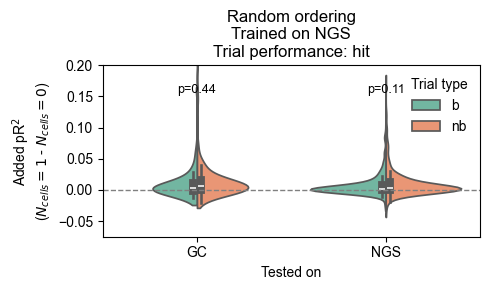

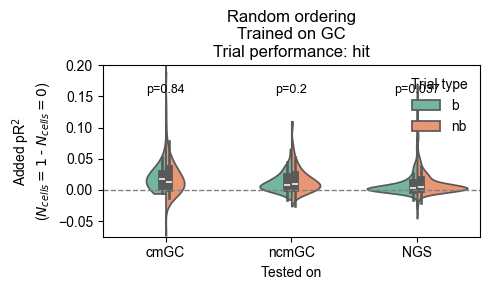

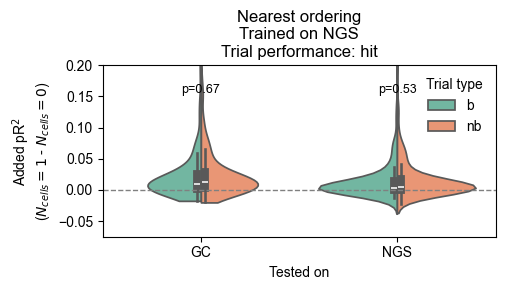

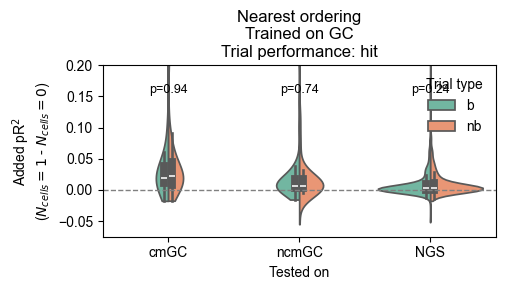

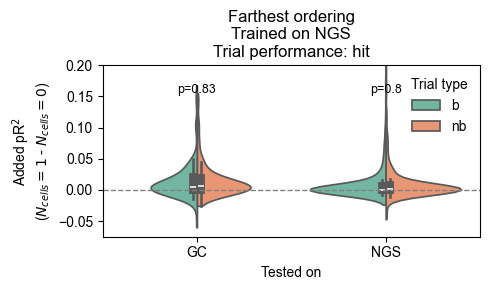

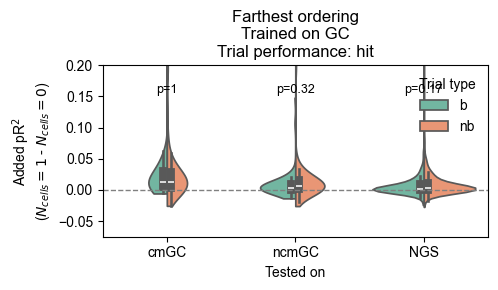

In [22]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

def get_added_pR2_trialtype(source_data, trained_on):
    added_pR2 = []
    # Only keep rows where trial_performance is 'hit'
    df = source_data[
        (source_data['trial_performance'] == 'hit') &
        (source_data['trained_on'] == trained_on) &
        (source_data['n_neurons'].isin([0, 1]))
    ]
    if trained_on == 'GC':
        test_on_list = ['cmGC', 'ncmGC', 'NGS']
    else:
        test_on_list = ['GC', 'NGS']

    for tested_on in test_on_list:
        for trial_type in df['trial_type'].unique():
            df_plot = df[(df['tested_on'] == tested_on) & (df['trial_type'] == trial_type)]
            if not set([0, 1]).issubset(df_plot['n_neurons'].unique()):
                continue
            pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
            pivot = pivot.dropna(subset=[0, 1])
            if 0 not in pivot.columns or 1 not in pivot.columns:
                continue
            diff = pivot[1] - pivot[0]
            temp_df = pd.DataFrame({
                'added_pR2': diff,
                'tested_on': tested_on,
                'trial_type': trial_type
            })
            added_pR2.append(temp_df)
    if added_pR2:
        return pd.concat(added_pR2, ignore_index=True)
    else:
        return pd.DataFrame(columns=['added_pR2', 'tested_on', 'trial_type'])

# Collect data for each source and trained_on
all_added_pR2_trialtype = []
for source, source_data in zip(['random', 'nearest', 'farthest'], [random_data, nearest_data, farthest_data]):
    for trained_on in ['NGS', 'GC']:
        temp = get_added_pR2_trialtype(source_data, trained_on)
        temp['source'] = source
        temp['trained_on'] = trained_on
        all_added_pR2_trialtype.append(temp)
all_added_pR2_trialtype = pd.concat(all_added_pR2_trialtype, ignore_index=True)

palette = {'GC': '#CAC841', 'NGS': '#6897CD'}
trialtype_palette = dict(zip(all_added_pR2_trialtype['trial_type'].unique(), sns.color_palette("Set2", n_colors=len(all_added_pR2_trialtype['trial_type'].unique()))))

for source in ['random', 'nearest', 'farthest']:
    for trained_on in ['NGS', 'GC']:
        plt.figure(figsize=(5, 3))
        subset = all_added_pR2_trialtype[
            (all_added_pR2_trialtype['source'] == source) &
            (all_added_pR2_trialtype['trained_on'] == trained_on)
        ]
        ax = sns.violinplot(
            x='tested_on',
            y='added_pR2',
            hue='trial_type',
            data=subset,
            split=True,
            inner='box',
            cut=0,
            palette=trialtype_palette
        )
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.ylabel('Added pR$^2$\n($N_{cells}=1$ - $N_{cells}=0$)')
        plt.xlabel('Tested on')
        plt.title(f'{source.capitalize()} ordering\nTrained on {trained_on}\nTrial performance: hit')
        plt.tight_layout()
        plt.ylim(-0.075, 0.2)
        plt.legend(title='Trial type', loc='upper right', frameon=False)

        # Annotate p-values comparing trial_types for each group
        if trained_on == 'GC':
            groups = ['cmGC', 'ncmGC', 'NGS']
        else:
            groups = ['GC', 'NGS']
        trial_types = subset['trial_type'].unique()
        y_max = 0.15
        for i, group in enumerate(groups):
            if len(trial_types) < 2:
                continue
            vals1 = subset[(subset['tested_on'] == group) & (subset['trial_type'] == trial_types[0])]['added_pR2']
            vals2 = subset[(subset['tested_on'] == group) & (subset['trial_type'] == trial_types[1])]['added_pR2']
            tstat, pval = ttest_ind(vals1, vals2, nan_policy='omit')
            ax.text(i, y_max, f"p={pval:.2g}", ha='center', va='bottom', fontsize=9, color='black')
        plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_trialtype_comparison_{source}_{trained_on}.pdf', dpi=300, bbox_inches='tight')
        plt.show()